# Notebook 2 — Resolve the Raghunath network to genes

**Goal.** Take the Raghunath (2015) directed, signed melanogenesis network (Notebook 1 output:
265 nodes / 429 edges, all typed offline) and turn it into a **gene-level network** — the object the
downstream analysis reasons over — while keeping the molecular topology beneath as traceable evidence.

**Scope of this notebook (revised).** This notebook does the *transformation only*: annotate every node,
resolve proteins to genes, make gene relationships explicit, and validate the mechanistic backbone against
OmniPath. **Enrichment with genes discovered since 2015 (HIrisPlex, GWAS Catalog, …) is a separate
notebook** — it is an addition *on top of* this network, not part of building it. Keeping the two apart
means this notebook is a clean, single-purpose object: the faithful gene-level image of Raghunath.

This notebook is organised as a sequence of explicit **Steps**, following one discipline throughout:

1. **Annotate before you enrich.** Steps 1–2 say *what each node is* using each entity type's own
   authority (a protein via a protein database, a compound via a chemical database, a process via an
   ontology). Gene vocabulary does **not** enter the annotation steps. Only *after* every node is typed do
   Steps 3–4 attach gene identity and gene-relationship edges.
2. **Every node and every edge carries at least one resolvable citation** (PMID/DOI or a citable database
   accession) — the same standard Raghunath applied to their edges, extended to the whole build. A closing
   gate fails the run if any element is uncited.
3. **All database calls are frozen.** Each response is captured verbatim to `data/external/db_responses/`,
   and every Step that depends on one shows the exact query and the date it was run behind a `REQUERY`
   guard. The notebook makes **no live network calls** — it replays the frozen responses and reproduces
   the same result on every run.

### Databases used, and why
| Database | Role in this notebook | Why this one |
|---|---|---|
| **UniProt** (reviewed/Swiss-Prot) | Step 1 — decide *is this node a protein* | Protein-sequence authority; reviewed entries are the standard for "this is a real human protein". Used gene-free (case-exact symbol match). |
| **ChEBI / PubChem** | Step 2 — small-molecule & peptide identity | Chemical-entity authorities; give a citable compound accession (ChEBI ID / PubChem CID). |
| **GO (via OLS)** | Step 2 — biological-process nodes | Ontology authority for process terms; each is a citable GO ID. |
| **MyGene.info** | Step 3 — gene identity for protein nodes | Aggregates HGNC/Entrez/Ensembl + GRCh38 coordinates in one call. **Enrichment only** — never used to decide node type. |
| **HGNC gene groups** | Step 4 — activity-class → member genes | Authoritative gene-family membership; each group is a citable HGNC group ID. |
| **OmniPath** | Step 6 — validate the backbone | Aggregates 11 interaction resources; used to *validate* the mechanistic backbone edges — never to add or overwrite them. |
| **KEGG hsa04916** | Step 6 — scope cross-check | Curated melanogenesis pathway; a membership reference, not an edge validator. |
| **HIrisPlex-S, GWAS Catalog** | **Separate enrichment notebook** | Post-2015 pigmentation genes are added on top of this network in their own notebook, not here. |


> **Key terms — so this notebook stands on its own** (you shouldn't need the other notebooks to read this one).
>
> - **Melanogenesis** — the cellular pathway that makes melanin, the pigment of skin, hair, and eyes. It is this project's mechanistic backbone: the set of genes/reactions whose wiring the whole analysis reasons over.
> - **Raghunath (2015) network** — a published melanogenesis reaction map (Raghunath et al. 2015). Notebook 1 turned it into a directed, signed graph of 265 nodes / 429 edges, with every node and edge typed and cited offline. That graph is the **input** to this notebook; here it is resolved to genes.
> - **Directed, signed graph** — a network whose edges carry both a direction (A acts on B, not just "A and B are linked") and a sign (+ = activation, − = repression). This is stronger than a plain association network.
> - **Mechanistic backbone** — this notebook's shorthand for those 429 directed/signed Raghunath edges: the molecular reaction-and-regulation topology, kept as the underlying cited evidence layer, as opposed to the gene-level edges built on top of it.
> - **Gene-level network (the deliverable)** — the Raghunath map re-expressed as gene→gene relationships: proteins resolved to their official genes, and non-gene intermediates (metabolites, complexes) contracted through so only gene→gene edges remain. This is the object downstream notebooks use.
> - **OmniPath** — a public database that aggregates many curated protein-interaction resources into signed, directed edges. Used here **only to validate** (cross-check) the backbone edges — never to add, remove, or overwrite them.
> - **Eumelanin / pheomelanin** — the two forms of melanin the pathway produces (brown-black and red-yellow, respectively). They are the pathway's outputs and are kept as terminal endpoint nodes in the topology layer.



## Setup

Load libraries and the two Notebook-1 outputs this notebook builds on:
`raghunath_nodes_typed.csv` (265 nodes) and `raghunath_edges_typed_signed.csv` (429 signed edges).
All paths are relative to the repo root.

In [1]:
import json, re
import pandas as pd, numpy as np, networkx as nx
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
PROC = ROOT / "data" / "processed"
FROZEN = ROOT / "data" / "external" / "db_responses"
FIG = ROOT / "notebooks" / "figures"
FIG.mkdir(parents=True, exist_ok=True)

# Notebook 1 outputs (the starting point)
nodes = pd.read_csv(PROC / "raghunath_nodes_typed.csv")
edges = pd.read_csv(PROC / "raghunath_edges_typed_signed.csv")
print("Raghunath network (Notebook 1):", len(nodes), "nodes,", len(edges), "edges")

pending = nodes[nodes.node_type == "pending_db_resolution"].copy()
print("nodes still needing type resolution:", len(pending),
      "| distinct base symbols:", pending.base.nunique())

# state-strip rule: only the documented IRAK1_Active -> IRAK1 case
def lookup_symbol(b):
    return re.sub(r"_(Active|active|phosphorylated|Phosphorylated|inactive)$", "", str(b))


Raghunath network (Notebook 1): 265 nodes, 429 edges
nodes still needing type resolution: 239 | distinct base symbols: 183


## Step 1 — Annotate the 1:1 proteins (UniProt)

**Question this Step answers:** *which base symbols are human proteins?* — and nothing about genes yet.

We ask the **protein** authority (UniProt reviewed / Swiss-Prot) directly, on the raw base symbols. A
symbol is annotated `protein` only when a reviewed human entry has a gene name that **case-exactly**
matches the raw symbol. The case-exact rule is load-bearing: it rejects `cAMP` (which case-folds onto
the gene *CAMP*, cathelicidin), `ROS` (→ *ROS1*), and other collisions that a naive symbol match would
wrongly call proteins.

*Why UniProt and not a gene database here:* "is this a protein" is a protein question. Using a gene
database to answer it would import the enrichment concept (genes) into the annotation — exactly the
muddle this restructure removes. Gene identity is attached later, in Step 3.

**Query (frozen).** `data/external/db_responses/uniprot_annotation_direct.json` —
`GET rest.uniprot.org/uniprotkb/search?query=(gene_exact:<SYM>) AND (organism_id:9606) AND (reviewed:true)`.

In [2]:
# --- frozen query provenance (re-runnable; set REQUERY=True to re-hit UniProt outside the sandbox) ---
REQUERY = False
if REQUERY:
    import urllib.request, urllib.parse, time
    syms = sorted(set(lookup_symbol(b) for b in pending.base.unique()))
    out = {}
    for s in syms:
        q = f'(gene_exact:{s}) AND (organism_id:9606) AND (reviewed:true)'
        url = "https://rest.uniprot.org/uniprotkb/search?" + urllib.parse.urlencode(
            {"query": q, "fields": "accession,id,gene_names,protein_name", "format": "json", "size": "5"})
        req = urllib.request.Request(url, headers={"Accept": "application/json"})
        with urllib.request.urlopen(req, timeout=30) as r:
            res = json.load(r)
        hits = [{"acc": d.get("primaryAccession"),
                 "gene_names": [g.get("geneName", {}).get("value") for g in d.get("genes", []) if g.get("geneName")]}
                for d in res.get("results", [])]
        out[s] = {"n": len(hits), "hits": hits}
        time.sleep(0.15)
    json.dump(out, open(FROZEN / "uniprot_annotation_direct.json", "w"))

uniprot_ann = json.load(open(FROZEN / "uniprot_annotation_direct.json"))
meta = json.load(open(FROZEN / "uniprot_annotation_direct.meta.json"))
print("UniProt annotation query date:", meta["queried_utc"])
print("rule:", meta["rule"])

UniProt annotation query date: 2026-07-09T00:49:37.132825+00:00
rule: node is a protein iff a reviewed human entry has gene_names containing the CASE-EXACT raw symbol


In [3]:
# --- deterministic annotation: case-exact reviewed protein ---
def is_caseexact_protein(base):
    lk = lookup_symbol(base)
    hits = uniprot_ann.get(lk, {}).get("hits", [])
    return any(lk in h.get("gene_names", []) for h in hits)

pending["is_protein_caseexact"] = pending.base.map(is_caseexact_protein)
n_prot = pending.is_protein_caseexact.sum()
print(f"case-exact reviewed proteins: {n_prot} / {pending.base.nunique()} base symbols")
print("rejected collisions (protein-looking but NOT case-exact):",
      [b for b in ['cAMP','ROS','cGMP'] if not is_caseexact_protein(b)])

case-exact reviewed proteins: 174 / 183 base symbols
rejected collisions (protein-looking but NOT case-exact): ['cAMP', 'ROS', 'cGMP']


## Step 2 — Annotate the other entity types

The 52 symbols that are **not** case-exact proteins are annotated by their own-type authority:

- **small molecule** → ChEBI / PubChem (a citable ChEBI ID or PubChem CID). Abbreviations are resolved
  by database synonym lookup, never by hand; the 8 that no unambiguous synonym search resolves carry a
  documented ruling (e.g. `Singlet_oxygen` → ChEBI:26689, overriding a chemically-wrong DB hit).
- **process** → GO biological-process term (a citable GO ID).
- **peptide ligand** → ACTH and α-MSH, curated ChEBI peptide-hormone entries (+ PubChem CID).
- **enzyme-activity / class** → the 6 nodes `PLA2, PKC, PLC, MMPs, Trypsin, Phosphodiesterase`. These
  name an **enzyme activity performed by a family of gene products**, not one gene. At annotation they
  get the type `enzyme_activity_class` and **no gene** — pinning an enzyme-activity class to a single
  representative gene would misrepresent it. Their full member genes are attached in Step 4, from a
  citable HGNC gene-group call.

These typings were frozen in the resolution cascade (`node_resolution.csv`, built in the repl tool and
committed); this Step loads that frozen table and reproduces the type assignment deterministically.

In [4]:
# frozen node-type resolution (small_molecule / process / peptide_ligand / enzyme_activity_class)
nr = pd.read_csv(PROC / "node_resolution.csv")

def annotate(row):
    b, lk = row["base"], lookup_symbol(row["base"])
    if row["node_type"] == "protein_family":     # -> enzyme-activity/class (no gene here)
        return pd.Series({"node_type": "enzyme_activity_class",
                          "type_source": "documented_ruling_activity_class", "own_accession": "",
                          "annotation_note": "enzyme activity / protein class; member genes resolved in Step 4 (HGNC gene-group)."})
    if row["node_type"] == "protein":
        ce = is_caseexact_protein(b)
        return pd.Series({"node_type": "protein",
                          "type_source": "uniprot_reviewed_caseexact" if ce else "uniprot_reviewed_synonym",
                          "own_accession": "",
                          "annotation_note": "" if ce else "reviewed UniProt entry under a synonym; official symbol in Step 3."})
    if row["node_type"] in ("small_molecule", "peptide_ligand"):
        acc = row["chebi_xref"] if pd.notna(row.get("chebi_xref")) and str(row.get("chebi_xref")).strip() \
              else (f"CID:{int(row['pubchem_cid'])}" if pd.notna(row.get("pubchem_cid")) else "")
        return pd.Series({"node_type": row["node_type"], "type_source": row["type_source"],
                          "own_accession": acc, "annotation_note": ""})
    if row["node_type"] == "process":
        return pd.Series({"node_type": "process", "type_source": "go_biological_process",
                          "own_accession": row["type_evidence_id"], "annotation_note": ""})
    return pd.Series({"node_type": row["node_type"], "type_source": row["type_source"],
                      "own_accession": "", "annotation_note": ""})

annotation = nr[["base"]].join(nr.apply(annotate, axis=1))
annotation["resolved_name"] = nr["resolved_name"]
print("ANNOTATION (gene-free) — node types:")
print(annotation.node_type.value_counts().to_string())
assert "hgnc_symbol" not in annotation.columns and "entrez" not in annotation.columns, "annotation must be gene-free"
print("\nno gene columns present:", True)
print("enzyme_activity_class nodes:", annotation[annotation.node_type=='enzyme_activity_class'].base.tolist())

ANNOTATION (gene-free) — node types:
node_type
protein                  134
small_molecule            25
process                   16
enzyme_activity_class      6
peptide_ligand             2

no gene columns present: True
enzyme_activity_class nodes: ['MMPs', 'PKC', 'PLA2', 'PLC', 'Phosphodiesterase', 'Trypsin']


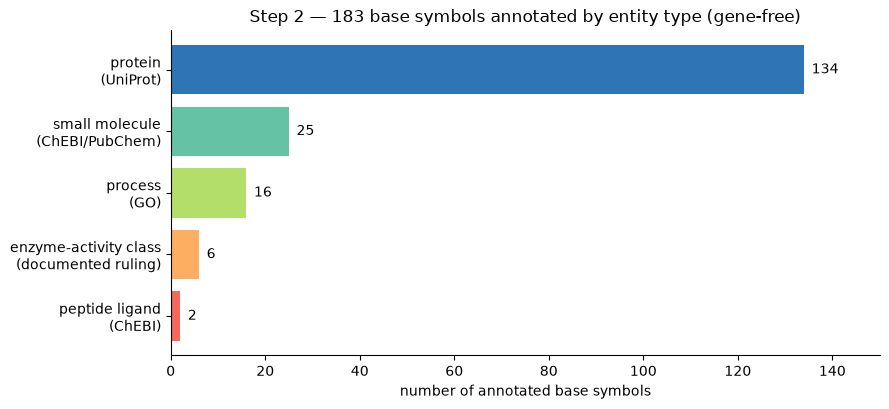

In [5]:
#| label: fig-nb2-annotation
#| fig-cap: "**Each non-protein network symbol is annotated by its own-type authority.** The 183 base symbols split into proteins (UniProt), small molecules (ChEBI/PubChem), processes (GO), enzyme-activity classes, and peptide ligands (ChEBI) — no gene database is used to type a non-gene entity."
# Figure — annotation composition (Step 2), built from `annotation` (this notebook's own
# in-memory table from cell 7), not from a stored image. Bar order = descending count, matching
# the value_counts() print above; colors distinguish the typing authority per entity type.
fig, ax = plt.subplots(figsize=(9, 4.2))

type_meta = {
    "protein": ("protein\n(UniProt)", "#2e75b6"),
    "small_molecule": ("small molecule\n(ChEBI/PubChem)", "#66c2a5"),
    "process": ("process\n(GO)", "#b3de69"),
    "enzyme_activity_class": ("enzyme-activity class\n(documented ruling)", "#fdae61"),
    "peptide_ligand": ("peptide ligand\n(ChEBI)", "#f4695c"),
}
counts = annotation.node_type.value_counts()  # already descending by count
order = list(counts.index)
labels = [type_meta[t][0] for t in order]
colors = [type_meta[t][1] for t in order]
values = [counts[t] for t in order]

y = np.arange(len(order))[::-1]  # largest bar on top
ax.barh(y, values, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(labels)
for yi, v in zip(y, values):
    ax.text(v + max(values) * 0.012, yi, str(v), va="center", fontsize=10)
ax.set_xlim(0, max(values) * 1.12)
ax.set_xlabel("number of annotated base symbols")
ax.set_title(f"Step 2 — {len(annotation)} base symbols annotated by entity type (gene-free)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

fig.savefig(FIG / "step2_annotation_types.png", dpi=150, bbox_inches="tight")
display(fig); plt.close(fig)  # exactly one embedded image/png, regardless of active backend


*Figure (Step 2).* The 183 base symbols after annotation, coloured by the authority that typed them.
134 proteins (UniProt), 25 small molecules (ChEBI/PubChem), 16 processes (GO), 6 enzyme-activity classes,
2 peptide ligands. No gene identity is attached at this stage.

## Step 3 — Attach gene identity to protein nodes (enrichment begins)

Annotation is done: every node has a type from its own authority. **Now** we enrich — and only now does
a gene database enter. Each `protein` node is mapped to its official HGNC symbol, Entrez ID, Ensembl gene,
UniProt accession, and GRCh38 coordinates via MyGene.info. The 3 synonym-only annotations resolve to
their official symbols here (IKBKA→CHUK, IL8→CXCL8, NFAT2→NFATC1).

Gene identity is a **separate layer** attached on top of the annotation — it does not overwrite the
node type or the source topology.

**Query (frozen).** `data/external/db_responses/mygene_raw.json` and `coords_raw.json`
(MyGene `query`/`querymany`, GRCh38).

In [6]:
# gene identity from the frozen MyGene resolution (committed in node_resolution.csv)
prot = annotation[annotation.node_type == "protein"].copy()
idcols = ["base","hgnc_symbol","entrez","ensembl","uniprot_acc","uniprot_confirmed","chr","start","end","strand"]
protein_enrichment = prot.merge(nr[idcols], on="base", how="left")

print("protein nodes enriched with gene identity:", len(protein_enrichment))
for c in ["hgnc_symbol","entrez","ensembl","uniprot_acc","chr"]:
    print(f"  with {c}: {protein_enrichment[c].notna().sum()}/{len(protein_enrichment)}")
print("\nsynonym -> official symbol:")
print(protein_enrichment[protein_enrichment.type_source=='uniprot_reviewed_synonym']
      [['base','hgnc_symbol','entrez','uniprot_acc']].to_string(index=False))

protein nodes enriched with gene identity: 134
  with hgnc_symbol: 134/134
  with entrez: 134/134
  with ensembl: 134/134
  with uniprot_acc: 134/134
  with chr: 134/134

synonym -> official symbol:
 base hgnc_symbol  entrez uniprot_acc
IKBKA        CHUK  1147.0      O15111
  IL8       CXCL8  3576.0      P10145
NFAT2      NFATC1  4772.0      O95644


## Step 4 — Build the explicit gene layer (nodes + typed edges)

The network model has one node = gene + protein via attributes; there is no explicit "this gene encodes
this protein" edge, and some entities relate to genes in ways a single 1:1 edge cannot capture. This Step
makes the gene relationships **explicit and typed**, as three edge classes — each carrying its own citation:

1. **`encodes`** (134 edges) — protein node ↔ its gene, 1:1. Cited by the identity accessions
   (UniProt + Entrez).
2. **`cleaved_from`** (2 edges) — the POMC prohormone cascade: **POMC → ACTH → α-MSH**. ACTH and α-MSH
   are not transcribed from their own genes; they are sequential proteolytic cleavage products of POMC.
   POMC is added as a gene node (Entrez 5443). Cited by PubMed PMIDs for the processing steps.
3. **`member_of_activity_class`** (115 edges) — each of the 6 enzyme-activity/class nodes → its **full**
   HGNC gene-group membership (no single representative). Cited by the HGNC gene-group ID.

**Query (frozen).** `hgnc_gene_groups.json` (HGNC `fetch/gene_group_id/<id>`) and
`pomc_cleavage_refs.json` (PubMed).

In [7]:
# --- frozen HGNC gene-group query provenance ---
REQUERY_HGNC = False
if REQUERY_HGNC:
    import urllib.request, urllib.parse
    def members(gid):
        url = f"https://rest.genenames.org/fetch/gene_group_id/{gid}"
        req = urllib.request.Request(url, headers={"Accept": "application/json"})
        with urllib.request.urlopen(req, timeout=40) as r:
            docs = json.load(r)["response"]["docs"]
        return sorted(d["symbol"] for d in docs if d.get("locus_type") == "gene with protein product")
    # group ids: PLA2=467(filter PLA2G*), MMPs=891, Trypsin=738(filter PRSS*), PDE=681, PKC=3523, PLC=832
    # (see hgnc_gene_groups.json for the frozen result + per-node filter notes)

hgg = json.load(open(FROZEN / "hgnc_gene_groups.json"))
pomc_refs = json.load(open(FROZEN / "pomc_cleavage_refs.json"))
print("HGNC gene groups (activity node -> members):")
for node, g in hgg.items():
    print(f"  {node}: {g['name']} [{g['hgnc_group_citation']}] -> {g['n']} member genes")

HGNC gene groups (activity node -> members):
  PLA2: Phospholipases [HGNC:GG:467] -> 20 member genes
  MMPs: M10 matrix metallopeptidases [HGNC:GG:891] -> 23 member genes
  Trypsin: Serine proteases [HGNC:GG:738] -> 25 member genes
  Phosphodiesterase: Phosphodiesterases [HGNC:GG:681] -> 24 member genes
  PKC: Protein kinase C family [HGNC:GG:3523] -> 9 member genes
  PLC: C2 domain containing phospholipases [HGNC:GG:832] -> 14 member genes


In [8]:
# --- build the three typed edge classes ---
gene_edges = []
# 4a: encodes
for _, r in protein_enrichment.iterrows():
    gene_edges.append({"edge_type": "encodes", "gene": r.hgnc_symbol, "target_node": r.base,
                       "citation": f"UniProt:{r.uniprot_acc}|Entrez:{int(r.entrez)}", "citation_source": "accession"})
# 4b: cleaved_from (POMC -> ACTH -> alpha-MSH)
pomc_pmids = ";".join(f"PMID:{p}" for p in pomc_refs["pomc_processing"][:2])
msh_pmids  = ";".join(f"PMID:{p}" for p in pomc_refs["msh_cleavage"][:2])
gene_edges += [
    {"edge_type": "cleaved_from", "gene": "POMC", "target_node": "ACTH",     "citation": pomc_pmids, "citation_source": "pmid"},
    {"edge_type": "cleaved_from", "gene": "ACTH", "target_node": "alpha_MSH", "citation": msh_pmids,  "citation_source": "pmid"}]
# 4c: member_of_activity_class
for node, g in hgg.items():
    for m in g["members"]:
        gene_edges.append({"edge_type": "member_of_activity_class", "gene": m, "target_node": node,
                           "citation": g["hgnc_group_citation"], "citation_source": "hgnc_gene_group"})
gene_layer = pd.DataFrame(gene_edges)
print("gene-layer edges:", len(gene_layer))
print(gene_layer.edge_type.value_counts().to_string())
assert (gene_layer.citation.str.strip() != "").all(), "every gene-layer edge must be cited"
print("all gene-layer edges cited:", True)

gene-layer edges: 251
edge_type
encodes                     134
member_of_activity_class    115
cleaved_from                  2
all gene-layer edges cited: True


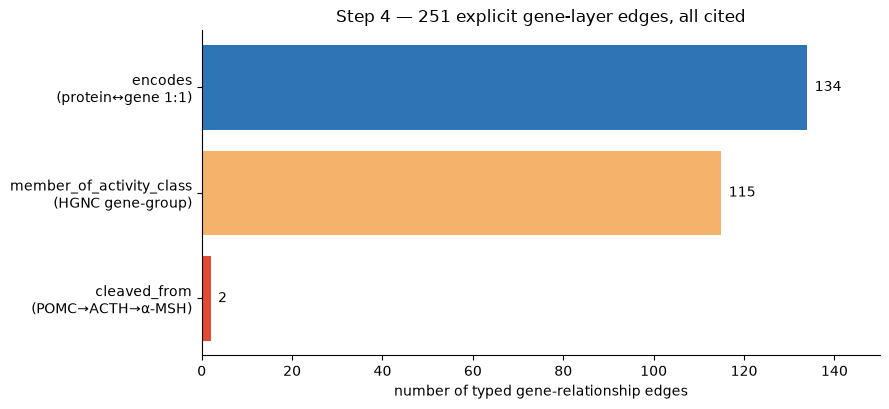

In [9]:
#| label: fig-nb2-genelayer
#| fig-cap: "**The explicit gene layer carries 251 typed, cited edges.** Edges are one of three relationship classes — protein↔gene encoding, HGNC gene-group membership, or POMC→ACTH→α-MSH cleavage — each traceable to a named source."
# Figure — the three typed gene-relationship edge classes (Step 4), built from `gene_layer`
# (cell 14's own in-memory table), not from a stored image.
fig, ax = plt.subplots(figsize=(9, 4.2))

edge_meta = {
    "encodes": ("encodes\n(protein↔gene 1:1)", "#2e75b6"),
    "member_of_activity_class": ("member_of_activity_class\n(HGNC gene-group)", "#f5b26b"),
    "cleaved_from": ("cleaved_from\n(POMC→ACTH→α-MSH)", "#e34a33"),
}
counts = gene_layer.edge_type.value_counts()
order = list(counts.index)
labels = [edge_meta[t][0] for t in order]
colors = [edge_meta[t][1] for t in order]
values = [counts[t] for t in order]

y = np.arange(len(order))[::-1]
ax.barh(y, values, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(labels)
for yi, v in zip(y, values):
    ax.text(v + max(values) * 0.012, yi, str(v), va="center", fontsize=10)
ax.set_xlim(0, max(values) * 1.12)
ax.set_xlabel("number of typed gene-relationship edges")
ax.set_title(f"Step 4 — {len(gene_layer)} explicit gene-layer edges, all cited")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

fig.savefig(FIG / "step4_gene_layer_edges.png", dpi=150, bbox_inches="tight")
display(fig); plt.close(fig)


*Figure (Step 4).* The three typed gene-relationship edge classes. `encodes` is 1:1; `member_of_activity_class`
expands the 6 activity nodes to their full HGNC gene-group membership; `cleaved_from` encodes the POMC→ACTH→α-MSH
cascade. Every edge carries a citation (accession, HGNC group ID, or PMID).

## Step 5 — Collapse, reify, and build the gene network

Assemble the gene network. Gene-gene edges are the **mechanistic backbone projected onto genes** — the 429
signed Raghunath edges, collapsed across compartments and contracted through non-gene intermediates
(metabolites, complexes) to leave gene→gene relationships. Each projection edge inherits the citation(s) of
the backbone edge(s) it derives from.

Node set: the 161 canonical protein genes (134 base symbols + complex members reified as their own gene
nodes, e.g. EP300, LEF1) + the 6 enzyme-activity/class nodes + POMC = **168 gene nodes**. The molecular
topology (493 topology edges: 429 backbone + 64 `member_of` *container* edges — complex/family membership, distinct from the 115 gene-layer `member_of_activity_class` edges built in Step 4) is **retained beneath** as a cited evidence
layer; the pigmentation endpoints (eumelanin, pheomelanin, and the biological-process outcomes) stay as
terminal nodes in that topology layer.

Network metrics are **recomputed on this graph** — published values are validation references only.

**A note on multiplicity.** The projection table keeps one row per distinct mechanistic path, so a gene
pair reached through two different relays (e.g. `ADCY4→PRKACA` via cAMP in the melanocyte vs keratinocyte
compartment) appears as two rows with different `via` intermediates. We report both the **physical row
count** and the **distinct directed-pair count**, and compute graph metrics on the simple (deduplicated)
graph.

In [10]:
# --- projection edges with inherited backbone citations ---
projection = pd.read_csv(PROC / "nb2_projection_cited.csv")
backbone   = pd.read_csv(PROC / "nb2_backbone_cited.csv")
canon      = pd.read_csv(PROC / "gene_graph_nodes.csv")
print("projection (gene->gene mechanistic) edges:", len(projection),
      "| citation sources:", projection.citation_source.value_counts().to_dict())
print("backbone edges (topology layer beneath):", len(backbone), "| all cited:",
      (backbone.citation.fillna('').str.strip() != '').all())

# --- gene nodes: full 161 canonical protein set + POMC + 6 activity classes ---
sym2up = dict(zip(protein_enrichment.hgnc_symbol, protein_enrichment.uniprot_acc))
gnodes = []
for _, r in canon[canon.node_type == "protein"].iterrows():
    up = sym2up.get(r.hgnc_symbol, "")
    cit = f"UniProt:{up}" if up and str(up) != "nan" else (f"Entrez:{int(r.entrez)}" if pd.notna(r.entrez) else "")
    gnodes.append({"gene": r.hgnc_symbol, "entrez": r.entrez, "ensembl": r.ensembl, "chr": r.chr,
                   "node_class": "network_protein_gene", "citation": cit, "citation_source": "accession"})
gnodes.append({"gene": "POMC", "entrez": 5443, "ensembl": "ENSG00000115138", "chr": "2",
               "node_class": "cleavage_precursor_gene", "citation": "Entrez:5443|UniProt:P01189", "citation_source": "accession"})
for node, g in hgg.items():
    gnodes.append({"gene": node, "entrez": None, "ensembl": None, "chr": None,
                   "node_class": "enzyme_activity_class", "citation": g["hgnc_group_citation"], "citation_source": "hgnc_gene_group"})
gene_network_nodes = pd.DataFrame(gnodes).drop_duplicates(subset="gene")

# --- gene-gene edges: mechanistic projection only (enrichment lives in a separate notebook) ---
gene_network_edges = pd.DataFrame([
    {"source": r.source, "target": r.target, "sign": r.sign, "edge_class": "mechanistic_projection",
     "via": r.get("via", ""), "citation": r.citation, "citation_source": r.citation_source}
    for _, r in projection.iterrows()])
n_rows = len(gene_network_edges)
n_pairs = gene_network_edges[["source", "target"]].drop_duplicates().shape[0]
print("\nGENE NETWORK:", len(gene_network_nodes), "nodes,",
      n_rows, "edge rows (", n_pairs, "distinct directed pairs )")
print("node classes:", gene_network_nodes.node_class.value_counts().to_dict())

projection (gene->gene mechanistic) edges: 309 | citation sources: {'inherited_backbone': 202, 'relayed_backbone': 107}
backbone edges (topology layer beneath): 429 | all cited: True

GENE NETWORK: 168 nodes, 309 edge rows ( 298 distinct directed pairs )
node classes: {'network_protein_gene': 161, 'enzyme_activity_class': 6, 'cleavage_precursor_gene': 1}


In [11]:
# --- metrics recomputed on the final (simple) graph ---
G = nx.DiGraph()
for _, r in gene_network_nodes.iterrows(): G.add_node(r.gene, node_class=r.node_class)
for _, r in gene_network_edges.iterrows(): G.add_edge(r.source, r.target, sign=r.sign)
deg = dict(G.degree()); btw = nx.betweenness_centrality(G)
iso = [n for n in G if G.degree(n) == 0]
print(f"nodes={G.number_of_nodes()} distinct-pair edges={G.number_of_edges()} "
      f"self_loops={nx.number_of_selfloops(G)} weakly_connected_components={nx.number_weakly_connected_components(G)} "
      f"largest_component={len(max(nx.weakly_connected_components(G), key=len))} density={nx.density(G):.5f}")
print("isolated genes (degree 0):", len(iso),
      "- reified complex/family members + POMC; connect only via the gene-layer or topology")
print("\ntop 5 by degree:    ", sorted(deg.items(), key=lambda x:-x[1])[:5])
print("top 5 by betweenness:", [(g, round(b,4)) for g,b in sorted(btw.items(), key=lambda x:-x[1])[:5]])
print("\nbiology check — MITF rank by degree:", 1 + sorted(deg.values(), reverse=True).index(deg['MITF']),
      "| by betweenness:", 1 + sorted(btw.values(), reverse=True).index(btw['MITF']))

nodes=168 distinct-pair edges=298 self_loops=1 weakly_connected_components=29 largest_component=140 density=0.01062
isolated genes (degree 0): 28 - reified complex/family members + POMC; connect only via the gene-layer or topology

top 5 by degree:     [('NFKB1', 25), ('MITF', 22), ('FOS', 14), ('JUN', 13), ('AKT1', 12)]
top 5 by betweenness: [('NFKB1', 0.1803), ('PLC', 0.0871), ('MITF', 0.0795), ('CREB1', 0.071), ('AKT1', 0.0684)]

biology check — MITF rank by degree: 2 | by betweenness: 3


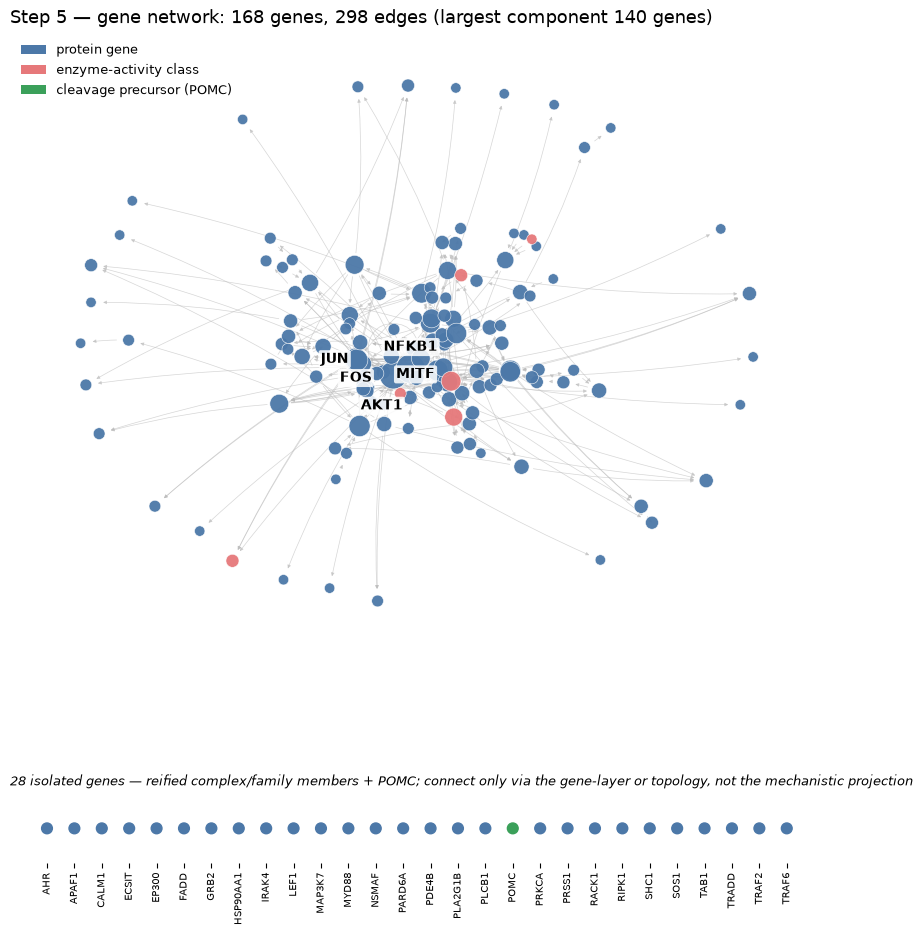

In [12]:
#| label: fig-nb2-genenetwork
#| fig-cap: "**The resolved gene network: 168 genes, 298 mechanistic edges.** The main component (140 genes) is drawn with node size scaled to degree and colour by node class; 28 reified complex/family members plus POMC are isolated, connecting only through the gene layer."
# Figure — the gene network graph (Step 5a), built from `G` (cell 19's own nx.DiGraph),
# not from a stored image. Node size scales with degree; color encodes node_class; layout is a
# seeded spring layout so the drawing is deterministic across re-runs. Isolated genes (degree 0)
# are drawn explicitly in a strip beneath the main panel — nothing is hidden.
from matplotlib.patches import Patch

NODE_CLASS_COLOR = {
    "network_protein_gene": "#4c78a8",
    "enzyme_activity_class": "#e6787a",
    "cleavage_precursor_gene": "#3ba05a",
}
NODE_CLASS_LABEL = {
    "network_protein_gene": "protein gene",
    "enzyme_activity_class": "enzyme-activity class",
    "cleavage_precursor_gene": "cleavage precursor (POMC)",
}

iso_nodes = sorted([n for n in G if deg[n] == 0])
core_nodes = [n for n in G if deg[n] > 0]
Gcore = G.subgraph(core_nodes)

pos = nx.spring_layout(Gcore, k=0.6, iterations=300, seed=7)  # seeded => deterministic layout

fig, (ax, axiso) = plt.subplots(
    2, 1, figsize=(10.5, 10.8), gridspec_kw={"height_ratios": [9, 1], "hspace": 0.4})

ncol = [NODE_CLASS_COLOR[G.nodes[n]["node_class"]] for n in core_nodes]
nsize = [40 + deg[n] * 16 for n in core_nodes]
nx.draw_networkx_edges(Gcore, pos, ax=ax, edge_color="#bbbbbb", width=0.5, alpha=0.6,
                        arrows=True, arrowsize=5, arrowstyle="-|>", connectionstyle="arc3,rad=0.05")
nx.draw_networkx_nodes(Gcore, pos, ax=ax, node_color=ncol, node_size=nsize,
                        edgecolors="white", linewidths=0.4, alpha=0.95)

top_hubs = sorted(deg, key=deg.get, reverse=True)[:5]
label_offsets = [(0, 13), (16, -2), (0, -16), (-16, -2), (16, 12)]
for n, (dx, dy) in zip(top_hubs, label_offsets):
    x, y = pos[n]
    ax.annotate(n, (x, y), xytext=(dx, dy), textcoords="offset points",
                fontsize=10, fontweight="bold", ha="center",
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.85))

ax.axis("off")
legend_handles = [Patch(fc=NODE_CLASS_COLOR[k], label=NODE_CLASS_LABEL[k])
                   for k in ["network_protein_gene", "enzyme_activity_class", "cleavage_precursor_gene"]]
ax.legend(handles=legend_handles, loc="upper left", frameon=False, fontsize=9)
ax.set_title(
    f"Step 5 — gene network: {G.number_of_nodes()} genes, {G.number_of_edges()} edges "
    f"(largest component {len(max(nx.weakly_connected_components(G), key=len))} genes)",
    fontsize=13, loc="left")

axiso.scatter(range(len(iso_nodes)), [0] * len(iso_nodes),
              color=[NODE_CLASS_COLOR[G.nodes[n]["node_class"]] for n in iso_nodes], s=60)
axiso.set_xticks(range(len(iso_nodes)))
axiso.set_xticklabels(iso_nodes, rotation=90, fontsize=7)
axiso.set_yticks([])
for spine in axiso.spines.values():
    spine.set_visible(False)
axiso.set_title(
    f"{len(iso_nodes)} isolated genes — reified complex/family members + POMC; "
    "connect only via the gene-layer or topology, not the mechanistic projection",
    fontsize=9, style="italic", loc="left")

fig.savefig(FIG / "step5_network_overview.png", dpi=150, bbox_inches="tight")
display(fig); plt.close(fig)


*Figure (Step 5a).* The gene network. The main panel shows the connected component (edge-bearing genes;
node size ∝ degree, colour by node type); the strip beneath shows the isolated genes explicitly — reified
complex/family members and POMC that connect only through the gene-layer or topology, not the mechanistic
projection. Nothing is hidden: every node in the table is drawn.

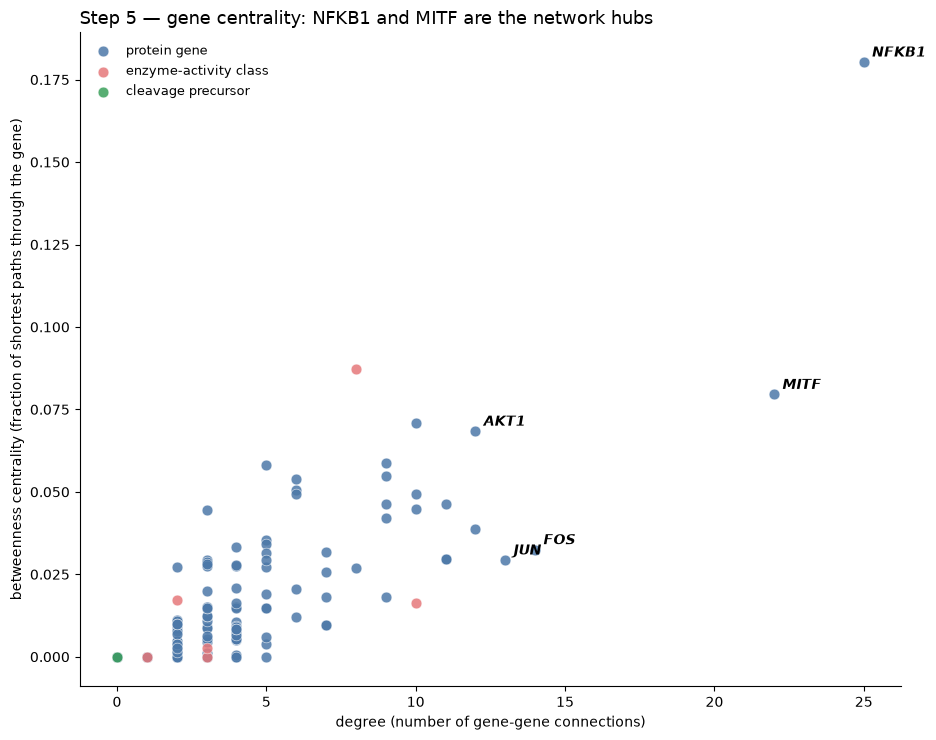

In [13]:
#| label: fig-nb2-centrality
#| fig-cap: "**NFKB1 and MITF are the network hubs.** Betweenness centrality plotted against degree for every gene, coloured by node class; the labelled genes carry the most shortest paths through the network."
# Figure — degree x betweenness centrality (Step 5b), built from `deg`/`btw` (already computed
# in cell 19, in scope here), not from a stored image.
NODE_CLASS_COLOR = {
    "network_protein_gene": "#4c78a8",
    "enzyme_activity_class": "#e6787a",
    "cleavage_precursor_gene": "#3ba05a",
}
NODE_CLASS_LABEL = {
    "network_protein_gene": "protein gene",
    "enzyme_activity_class": "enzyme-activity class",
    "cleavage_precursor_gene": "cleavage precursor",
}

fig, ax = plt.subplots(figsize=(9.5, 7.5))
for cls, color in NODE_CLASS_COLOR.items():
    ns_cls = [n for n in G if G.nodes[n]["node_class"] == cls]
    ax.scatter([deg[n] for n in ns_cls], [btw[n] for n in ns_cls],
               s=60, color=color, edgecolor="white", linewidth=0.4, alpha=0.85,
               label=NODE_CLASS_LABEL[cls])

top5 = sorted(deg, key=deg.get, reverse=True)[:5]
for n in top5:
    ax.annotate(n, (deg[n], btw[n]), xytext=(6, 4), textcoords="offset points",
                fontsize=10, fontweight="bold", fontstyle="italic")

ax.set_xlabel("degree (number of gene-gene connections)")
ax.set_ylabel("betweenness centrality (fraction of shortest paths through the gene)")
ax.set_title(f"Step 5 — gene centrality: {top5[0]} and {top5[1]} are the network hubs", loc="left", fontsize=13)
ax.legend(loc="upper left", frameon=False, fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

fig.savefig(FIG / "step5_centrality.png", dpi=150, bbox_inches="tight")
display(fig); plt.close(fig)


*Figure (Step 5b).* Gene centrality as a **degree × betweenness** scatter (colour = node type). Placing
the two metrics on separate axes keeps magnitude and category from colliding. **MITF**, the master
melanogenesis regulator, and **NFKB1** sit at the top of both axes — an independent check that the
projection preserved the network's hub structure.

## Step 6 — Validate edges against OmniPath (a separate joined table)

OmniPath is used here **only to validate** the mechanistic backbone — never to add or overwrite edges.
Each of the 429 backbone edges gets a **four-way verdict**, in a separate joined table:

- **confirmed** — OmniPath carries the edge and its sign agrees (188);
- **not_in_omnipath** — both endpoints are protein-coding genes but OmniPath has no such edge across its
  11 datasets (40);
- **sign_conflict** — OmniPath carries the edge with the opposite sign (3). This is documented as
  **"differs from cross-tissue consensus"**, *not* "wrong": Raghunath's edges are tissue-specific
  (keratinocyte/melanocyte), and a tissue-specific signed edge can legitimately differ from OmniPath's
  pan-tissue aggregate;
- **out_of_scope** — at least one endpoint is a metabolite / process / peptide, which OmniPath's
  protein-protein interaction scope does not cover (198).

A **KEGG hsa04916** (curated melanogenesis pathway) membership column is added as a scope cross-check — a
membership reference, not an edge validator.

**Query (frozen, re-runnable).** `omnipath_internal.json` (OmniPath interactions, both endpoints in the
resolved gene set) + `omnipath.meta.json` (exact query + date). Set `REQUERY_OMNIPATH=True` to re-hit the
API and re-freeze.

In [14]:
# --- frozen OmniPath query provenance ---
REQUERY_OMNIPATH = False
op_meta = json.load(open(FROZEN / "omnipath.meta.json"))
print("OmniPath query date:", op_meta.get("queried_utc"))
print("datasets:", op_meta.get("datasets", op_meta.get("params", {}).get("datasets", "see meta")))
if REQUERY_OMNIPATH:
    # documented in omnipath.meta.json: GET omnipathdb.org/interactions
    #   ?genesymbols=1&organisms=9606&datasets=<11 datasets>&partners=<resolved gene set>
    # re-freeze both-endpoints-in-set subset to omnipath_internal.json
    pass

op = json.load(open(FROZEN / "omnipath_internal.json"))
kegg = set(json.load(open(FROZEN / "kegg_hsa04916.json"))["symbols"])
op_lookup = {}
for e in op:
    s, t = e.get("source_genesymbol"), e.get("target_genesymbol")
    if s and t: op_lookup.setdefault((s, t), []).append(e)
print("OmniPath internal edges:", len(op), "| distinct directed gene-pairs:", len(op_lookup),
      "| KEGG hsa04916 genes:", len(kegg))

OmniPath query date: 2026-07-09T00:37:21.317544+00:00
datasets: omnipath,pathwayextra,kinaseextra,ligrecextra,dorothea,collectri,tf_target,mirnatarget,tf_mirna,lncrna_mrna,small_molecule
OmniPath internal edges: 2931 | distinct directed gene-pairs: 2638 | KEGG hsa04916 genes: 101


In [15]:
# --- four-way verdict ---
base2sym = dict(zip(nr.base, nr.hgnc_symbol))
def node2sym(n):
    b = re.sub(r'_(kerat|melan)$', '', str(n)); b = re.sub(r'_(Active|active)$', '', b)
    return base2sym.get(b, b)
prot_syms = set(nr[nr.node_type == "protein"].hgnc_symbol) | {"CHUK","CXCL8","NFATC1"}
val = backbone.copy()
val["src_sym"] = val.source.map(node2sym); val["tgt_sym"] = val.target.map(node2sym)

def verdict(row):
    s, t = row.src_sym, row.tgt_sym
    if s not in prot_syms or t not in prot_syms:
        return pd.Series({"verdict": "out_of_scope", "omnipath_sign": "", "note": "endpoint not a protein-coding gene"})
    hits = op_lookup.get((s, t), [])
    if not hits:
        return pd.Series({"verdict": "not_in_omnipath", "omnipath_sign": "", "note": "no OmniPath edge across 11 datasets"})
    stim = any(h.get("is_stimulation") for h in hits); inhib = any(h.get("is_inhibition") for h in hits)
    op_sign = "+" if stim and not inhib else ("-" if inhib and not stim else ("+/-" if stim and inhib else "0"))
    rs = str(row.sign)
    if (rs == "+" and op_sign == "-") or (rs == "-" and op_sign == "+"):
        return pd.Series({"verdict": "sign_conflict", "omnipath_sign": op_sign, "note": "differs from cross-tissue consensus"})
    return pd.Series({"verdict": "confirmed", "omnipath_sign": op_sign, "note": ""})

val = val.join(val.apply(verdict, axis=1))
val["kegg_hsa04916_src"] = val.src_sym.isin(kegg); val["kegg_hsa04916_tgt"] = val.tgt_sym.isin(kegg)
print("FOUR-WAY VERDICT (429 backbone edges):")
print(val.verdict.value_counts().to_string())
print("\nsign-conflicts (differ from cross-tissue consensus, NOT wrong):")
print(val[val.verdict == "sign_conflict"][["src_sym","tgt_sym","sign","omnipath_sign"]].to_string(index=False))

FOUR-WAY VERDICT (429 backbone edges):
verdict
out_of_scope       198
confirmed          188
not_in_omnipath     40
sign_conflict        3

sign-conflicts (differ from cross-tissue consensus, NOT wrong):
src_sym tgt_sym sign omnipath_sign
  CASP3  CDKN1A    -             +
 MAPK14   CASP3    +             -
 TFAP2A     TNF    -             +


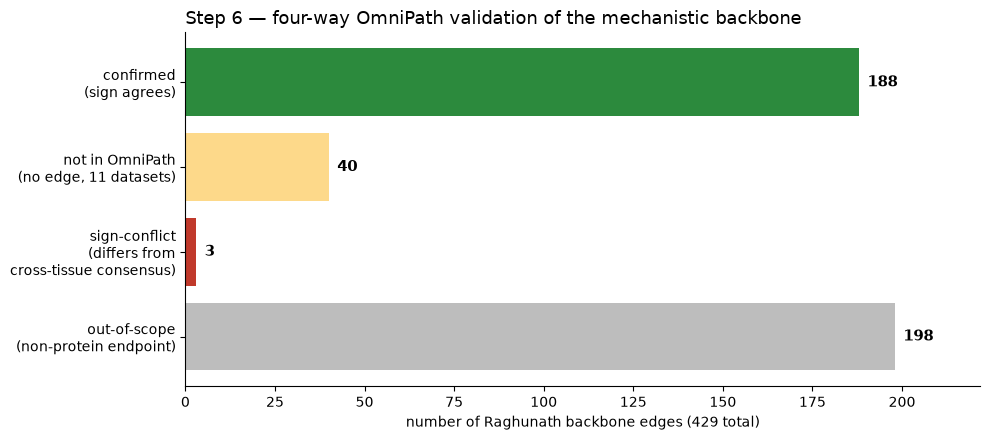

In [16]:
#| label: fig-nb2-omnipath
#| fig-cap: "**OmniPath independently validates the mechanistic backbone.** Of 429 Raghunath edges, 188 are confirmed (sign agrees), 3 sign-conflict, 40 are absent from OmniPath, and 198 fall out of scope (a non-protein endpoint) — a four-way verdict, never a silent edge addition."
# Figure — four-way OmniPath validation verdict (Step 6), built from `val` (cell 26's own
# joined table), not from a stored image.
fig, ax = plt.subplots(figsize=(10, 4.5))

verdict_meta = {
    "confirmed": ("confirmed\n(sign agrees)", "#2c8a3d"),
    "not_in_omnipath": ("not in OmniPath\n(no edge, 11 datasets)", "#fdd98a"),
    "sign_conflict": ("sign-conflict\n(differs from\ncross-tissue consensus)", "#c0392b"),
    "out_of_scope": ("out-of-scope\n(non-protein endpoint)", "#bdbdbd"),
}
order = ["confirmed", "not_in_omnipath", "sign_conflict", "out_of_scope"]
counts = val.verdict.value_counts()
labels = [verdict_meta[t][0] for t in order]
colors = [verdict_meta[t][1] for t in order]
values = [counts.get(t, 0) for t in order]

y = np.arange(len(order))[::-1]
ax.barh(y, values, color=colors)
ax.set_yticks(y)
ax.set_yticklabels(labels)
for yi, v in zip(y, values):
    ax.text(v + max(values) * 0.012, yi, str(v), va="center", fontsize=11, fontweight="bold")
ax.set_xlim(0, max(values) * 1.12)
ax.set_xlabel(f"number of Raghunath backbone edges ({len(val)} total)")
ax.set_title("Step 6 — four-way OmniPath validation of the mechanistic backbone", loc="left", fontsize=13)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

fig.savefig(FIG / "step6_validation_verdict.png", dpi=150, bbox_inches="tight")
display(fig); plt.close(fig)


*Figure (Step 6).* The four-way OmniPath validation of the 429 backbone edges. Most in-scope edges are
confirmed; the 3 sign-conflicts are flagged as differing from the cross-tissue consensus, not as errors.
The large out-of-scope bar reflects that much of the mechanistic backbone runs through metabolites and
processes, which a protein-protein interaction database does not cover.

## Step 7 — Citation gate + emit checkpoint

Two closing actions:

1. **Citation-completeness gate.** Every node and every edge — across the annotation, gene layer,
   backbone, projection, and validation tables — must carry at least one resolvable citation (PMID/DOI or a
   citable accession). Release-blocking: if any element is uncited, the assertion fails the run.
2. **Emit the checkpoint** — the gene network and every supporting table to `data/processed/`.

In [17]:
def citation_is_empty(v):
    return v is None or (isinstance(v, float) and pd.isna(v)) or (isinstance(v, str) and not v.strip())

def check_citations(tables, col="citation"):
    off, total = [], 0
    for name, df in tables.items():
        total += len(df)
        off += [(name, i) for i, v in df[col].items() if citation_is_empty(v)]
    return {"ok": len(off) == 0, "n_total": total, "n_uncited": len(off), "offenders": off}

report = check_citations({
    "gene_network_nodes": gene_network_nodes, "gene_layer_edges": gene_layer,
    "backbone": backbone, "projection": projection, "omnipath_validation": val})
print(f"citation gate: {report['n_total']} elements, {report['n_uncited']} uncited")
assert report["ok"], f"CITATION GATE FAILED: {report['offenders'][:10]}"
print("PASSED — every node and edge carries at least one resolvable citation.")

citation gate: 1586 elements, 0 uncited
PASSED — every node and edge carries at least one resolvable citation.


In [18]:
annotation.to_csv(PROC / "nb2_annotation.csv", index=False)
protein_enrichment.to_csv(PROC / "nb2_protein_enrichment.csv", index=False)
gene_layer.to_csv(PROC / "nb2_gene_layer_edges.csv", index=False)
gene_network_nodes.to_csv(PROC / "gene_network_nodes.csv", index=False)
gene_network_edges.to_csv(PROC / "gene_network_edges.csv", index=False)
val.to_csv(PROC / "nb2_omnipath_validation.csv", index=False)
print("checkpoint written to data/processed/:")
print("  gene_network_nodes.csv   ", len(gene_network_nodes), "gene nodes  <- the gene network")
print(f"  gene_network_edges.csv   {len(gene_network_edges)} edge rows "
      f"({gene_network_edges[['source','target']].drop_duplicates().shape[0]} distinct pairs)")
print("  + annotation, protein_enrichment, gene_layer, omnipath_validation")

checkpoint written to data/processed/:
  gene_network_nodes.csv    168 gene nodes  <- the gene network
  gene_network_edges.csv   309 edge rows (298 distinct pairs)
  + annotation, protein_enrichment, gene_layer, omnipath_validation


## Summary

Starting from the Raghunath directed signed network (265 nodes / 429 edges), this notebook produced a
**gene-level network of 168 gene nodes and 309 mechanistic edges** (298 distinct directed gene pairs), by a
strict annotate-then-enrich discipline:

- **Steps 1–2** annotated every node by its own-type authority (UniProt / ChEBI / PubChem / GO), with no
  gene vocabulary — including reclassifying the 6 former "protein_family" nodes as enzyme-activity/class.
- **Steps 3–4** attached gene identity (MyGene) and made gene relationships explicit as three typed, cited
  edge classes (`encodes`, `cleaved_from` for POMC→ACTH→α-MSH, `member_of_activity_class` from HGNC gene
  groups).
- **Step 5** built the gene network; recomputed metrics confirm MITF and NFKB1 as the top hubs.
- **Step 6** validated the backbone against OmniPath as a separate four-way table, documenting the 3
  sign-conflicts as cross-tissue differences.
- **Step 7** enforced the citation gate (every node and edge cited) and emitted the checkpoint.

The molecular topology is retained beneath the gene network as a cited evidence layer, and the pigmentation
endpoints are kept as terminal nodes.

**What this notebook deliberately does NOT do — enrichment.** Adding pigmentation genes discovered since
2015 (HIrisPlex-S, and potentially GWAS Catalog and other sources) is an **addition on top of this
network**, handled in a separate enrichment notebook. There, "in HIrisPlex" is treated as an *attribute a
gene can carry* (including genes already in Raghunath — KITLG, MC1R, OCA2, TYR, TYRP1 — which are in the
panel), not a separate node class, and the question of *which loci contribute most to phenotype prediction*
is developed with its own data.